In [1]:
import numpy as np

from weather.config import (
    Experiment,
    WeatherFixedParams,
    WeatherGridParams,
    MLPFixedParams,
    MLPGridParams,
    FitFixedParams,
    FitGridParams,
)

from weather.search import Search

from mlp.utils import (
    plot_loss,
    regression_report,
    classification_report_binary,
    plot_roc_auc,
    plot_accuracy,
)


In [2]:
SEED = 42
np.random.seed(SEED)


In [3]:
experiment = Experiment(
    name="wind_6plus_classification",

    # =========================
    # WEATHER
    # =========================
    weather_fixed=WeatherFixedParams(
        target="wind_speed",
        target_mode="binary",
        target_threshold=6.0,
        data_dir="../data",
        skip_day=True,
        normalization="global",
        encode_wind_direction=True,
    ),

    weather_grid=WeatherGridParams(
        window_aggregation=["flatten", "aggregate"],
        window_size=3,
        input_variables=(
            "temperature",
            "humidity",
            "pressure",
            "wind_speed",
            "wind_direction",
        ),
        aggregations={
            "temperature": ("mean", "min", "max"),
            "humidity": ("mean", "min", "max"),
            "pressure": ("mean", "min", "max"),
            "wind_speed": ("mean", "max"),
            "wind_direction": ("mean",),
        },
        cities=("Vancouver",),
    ),

    # =========================
    # MLP
    # =========================
    mlp_fixed=MLPFixedParams(
        task="binary",
        beta = 0.9,
        beta2 = 0.999,
        eps = 1e-8,
        adaptive_lr=True,
        lr_decay=0.99,
    ),

    mlp_grid=MLPGridParams(
        hidden_layers=(64, 64),
        loss="binary_cross_entropy",
        activation="gelu",
        learning_rate=0.008,
        seed=SEED,
        use_bias=True,
        optimizer="momentum",
    ),

    # =========================
    # FIT
    # =========================
    fit_fixed=FitFixedParams(
        verbose=True,
        log_every=None,
        use_tqdm=True,
        one_hot_if_needed=True,
        early_stopping=True,
        patience=20,
        min_delta=0.001,
    ),

    fit_grid=FitGridParams(
        epochs=400,
        batch_size="auto",
        shuffle=False,
        val_split=0.1,
    ),
)


In [4]:
# %pdb on

search = Search()

results = search.run(experiment)

# %pdb off


Vancouver | windows: 100%|██████████| 1518/1518 [00:05<00:00, 254.24it/s]
Vancouver | windows: 100%|██████████| 361/361 [00:01<00:00, 210.78it/s]


>>> Initializing MLP...
Layer sizes: [39, 64, 64, 1], Task: binary, Activation: gelu, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...


Training:  14%|█▍        | 57/400 [00:03<00:22, 15.55it/s, acc=0.6903, loss=0.5829, lr=0.00451124]


Early stopping at epoch 58, best val_loss=0.678524, train_acc=0.6903, val_acc=0.5433 after 20 epochs without improvement.
Training finished in 3.67 seconds


Vancouver | windows: 100%|██████████| 1518/1518 [00:05<00:00, 257.34it/s]
Vancouver | windows: 100%|██████████| 361/361 [00:01<00:00, 240.47it/s]


>>> Initializing MLP...
Layer sizes: [13, 64, 64, 1], Task: binary, Activation: gelu, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...


Training:  10%|▉         | 38/400 [00:03<00:30, 11.84it/s, acc=0.6868, loss=0.5916, lr=0.00546044]

Early stopping at epoch 39, best val_loss=0.675742, train_acc=0.6868, val_acc=0.5906 after 20 epochs without improvement.
Training finished in 3.21 seconds



EXPERIMENT: wind_6plus_classification
TASK: BINARY
=== TEST METRICS (BINARY CLASSIFICATION) ===
Accuracy : 0.5030
Precision: 0.6218
Recall   : 0.3854
F1       : 0.4759
AUC      : 0.5517


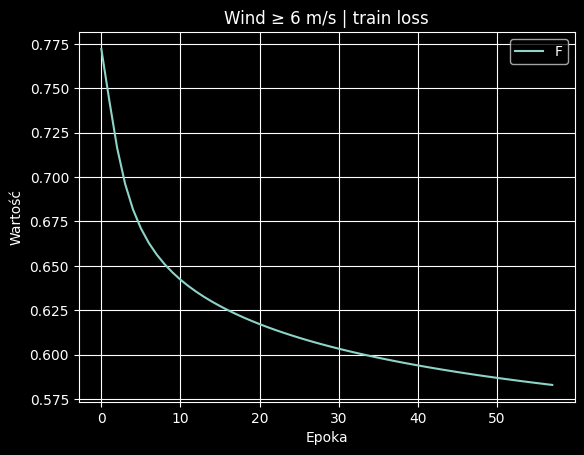

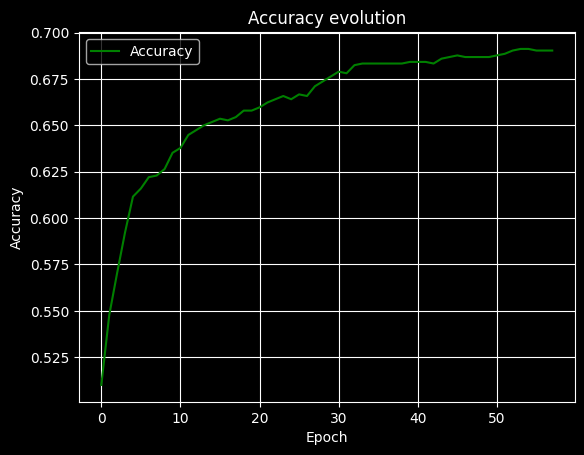

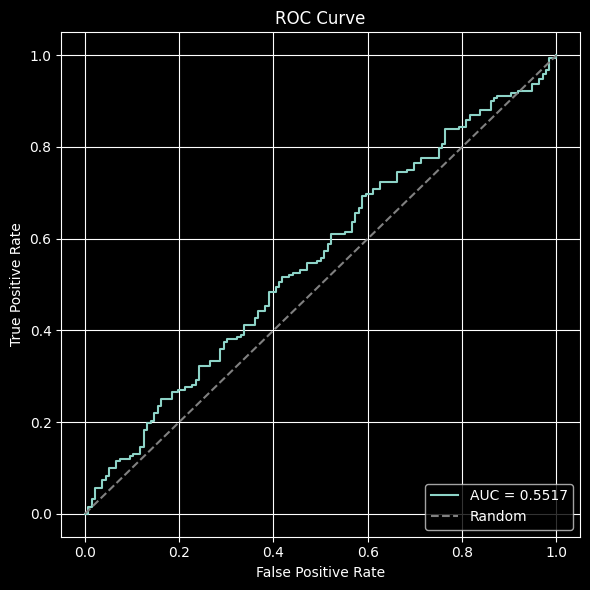


EXPERIMENT: wind_6plus_classification
TASK: BINARY
=== TEST METRICS (BINARY CLASSIFICATION) ===
Accuracy : 0.5152
Precision: 0.6051
Recall   : 0.4948
F1       : 0.5444
AUC      : 0.5114


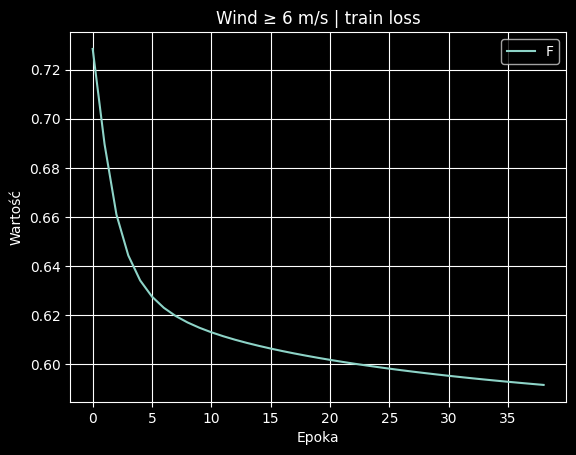

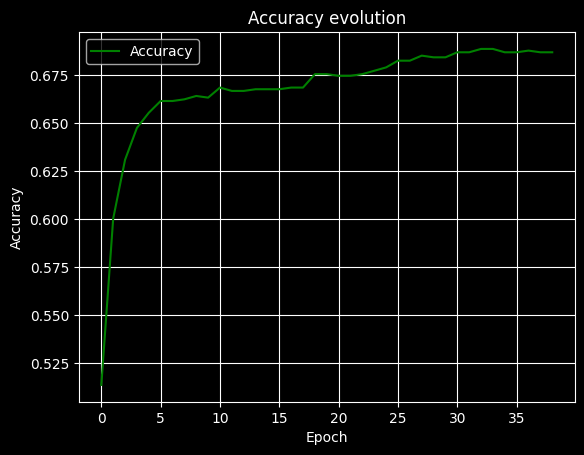

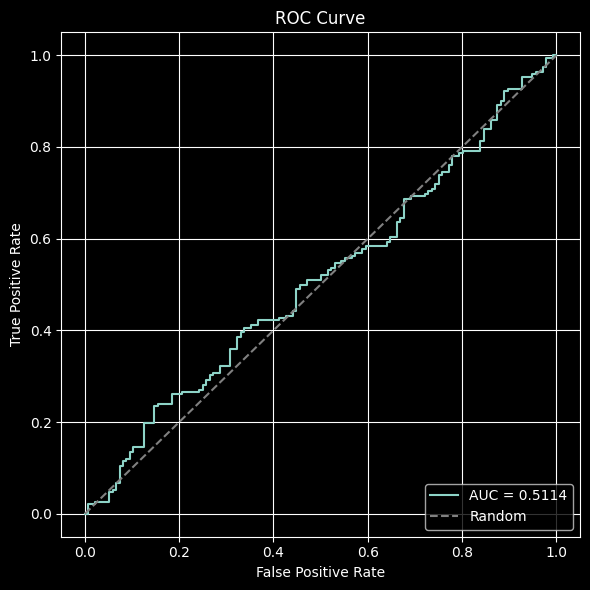

In [6]:
for run in results:
    model = run["model"]
    y_test = run["y_test"]
    y_pred = run["y_pred"]
    y_proba = run["y_proba"]

    history = run["history"]
    accuracy_history = run["accuracy_history"]

    print("\n" + "=" * 80)
    print(f"EXPERIMENT: {run['experiment']}")
    print(f"TASK: {model.task.upper()}")
    print("=" * 80)

    # ===================== METRICS =====================
    if model.task == "binary":
        metrics = classification_report_binary(
            y_true=y_test,
            y_score=y_proba,   # probabilities, NOT labels
            threshold=0.5,
        )

        print("=== TEST METRICS (BINARY CLASSIFICATION) ===")
        print(f"Accuracy : {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall   : {metrics['recall']:.4f}")
        print(f"F1       : {metrics['f1']:.4f}")
        print(f"AUC      : {metrics['auc']:.4f}")

    else:  # regression (and safe fallback)
        metrics = regression_report(
            y_true=y_test,
            y_pred=y_pred,
        )

        print("=== TEST METRICS (REGRESSION) ===")
        print(f"MAE  : {metrics['mae']:.4f}")
        print(f"MSE  : {metrics['mse']:.4f}")
        print(f"RMSE : {metrics['rmse']:.4f}")
        print(f"R²   : {metrics['r2']:.4f}")

    # --- plots ---
    plot_loss(
        history,
        title="Wind ≥ 6 m/s | train loss",
    )

    if model.task != "regression":
        if accuracy_history and not all(np.isnan(accuracy_history)):
            plot_accuracy(
                accuracy_history,
                title="Accuracy evolution",
            )

    # ROC only for binary classification
    if model.task == "binary":
        plot_roc_auc(
            y_true=y_test,
            y_score=y_proba,
            title="ROC Curve",
        )
